In [1]:
%load_ext autoreload
%autoreload 2
%aimport src_config

In [2]:
%%time
from lab.degiroUtils import downloader, anagrafica_builder, compute_log_ret
import degiroapi
from pathlib import Path
import pandas as pd

import numpy as np
from lab.degiroUtils import _MODEL_STATS_PATH_    # "C:\\Users\\fontanesio\\Documents\\pythonScripts\\progetti\\personali\\laboratorio\\file\\processed\\parquet\\"
from lab.degiroUtils import _MODEL_PATH_          # "C:\\Users\\fontanesio\\Documents\\pythonScripts\\progetti\\personali\\laboratorio\\file\\processed\\models\\"

Wall time: 7.33 s


In [3]:
%%time
pd.options.display.max_columns = 200

raw_file_path = Path("C:\\Users\\fontanesio\\Documents\\pythonScripts\\progetti\\personali\\laboratorio\\file\\raw\\")

degiro = degiroapi.DeGiro()
degiro.login("Calsipher8", "Palazov13!")

index_id=6
stock_country_id=906

downloader(degiro, index_id=index_id, stock_country_id=stock_country_id, raw_file_path=raw_file_path)

dax_anagrafica_test = pd.read_parquet(raw_file_path / f"{index_id}_{stock_country_id}_anagrafica.parquet", engine="fastparquet")
ts_dax = pd.read_parquet(raw_file_path / f"{index_id}_{stock_country_id}_ts.parquet", engine="fastparquet")

39
Faild stocks 0
Success stocks 40


Pandas Apply: 100%|██████████| 40/40 [00:00<00:00, 117.26it/s]


Wall time: 36.1 s


In [34]:
ret_ts = compute_log_ret(ts=ts_dax, price_threshold=100)
ret_ts.head()

,DE000BASF111,DE000BAY0017,DE0005190003,DE000A1DAHH0,DE0006062144,DE0007100000,DE0005140008,DE0005552004,DE0005557508,DE000A0HN5C6,DE000ENAG999,DE0005785802,DE0005785604,DE0006047004,DE000A161408,DE0006048432,DE0006231004,NL0012169213,DE0007037129,DE000ENER6Y0,DE000SHL1006,DE000A1ML7J1
DATE,,,,,,,,,,,,,,,,,,,,,,
2019-10-31,0.003143,0.006473,-0.001582,0.007129,-0.003889,-0.003836,0.069929,0.011433,0.008211,0.031949,-0.015814,-0.007238,-0.018381,0.001855,0.047034,0.008831,-0.000127,0.018600,-0.009714,-0.004451,0.013116,-0.007088
2019-11-01,-0.006454,-0.005442,-0.009318,-0.010165,-0.006753,-0.004454,-0.019168,-0.025440,-0.005262,0.008312,-0.012352,0.042503,0.034858,-0.009623,-0.004529,-0.018004,-0.005876,-0.006375,-0.021402,-0.040552,-0.001672,0.004110
2019-11-04,-0.006814,-0.005162,-0.022398,0.006063,-0.012561,-0.009455,-0.005323,0.008055,0.006116,0.010150,0.011802,-0.008455,-0.006436,-0.003124,-0.004043,0.017746,-0.009720,-0.011147,0.017339,0.012798,-0.010429,0.007799
2019-11-05,-0.000477,-0.004252,-0.016362,-0.009108,-0.006704,-0.005985,-0.003622,-0.012012,0.006443,0.007971,-0.004409,0.008131,0.003284,-0.002820,0.003287,-0.008051,-0.019399,-0.010619,-0.011221,0.004783,-0.007809,-0.005565
2019-11-06,0.009815,0.001039,0.004854,-0.000366,0.005981,0.001714,-0.007284,-0.001795,0.000727,0.001134,-0.005724,-0.006337,-0.010621,0.008125,0.019001,-0.003396,-0.007281,-0.006338,0.002437,0.011551,0.001022,0.008151


<AxesSubplot:ylabel='Frequency'>

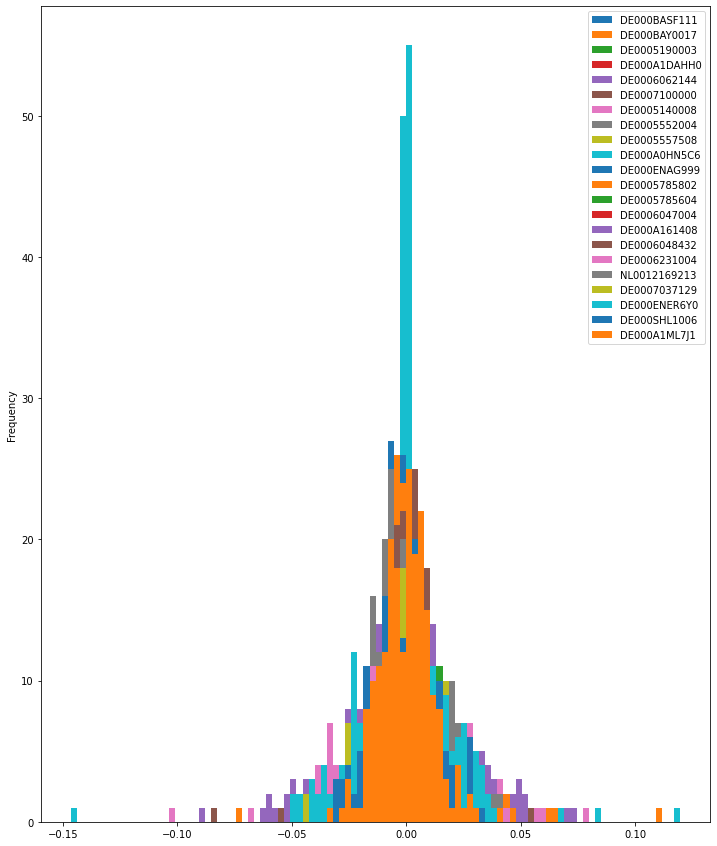

In [39]:
ret_ts.plot.hist(bins=100, figsize=(12, 15))

<AxesSubplot:xlabel='DATE'>

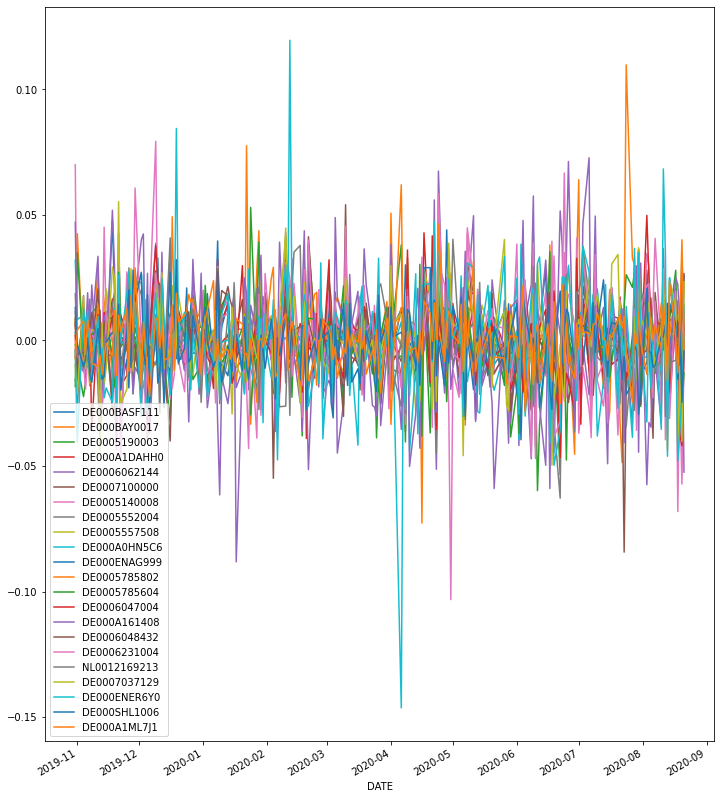

In [40]:
ret_ts.plot(figsize=(12, 15))

<AxesSubplot:xlabel='DATE'>

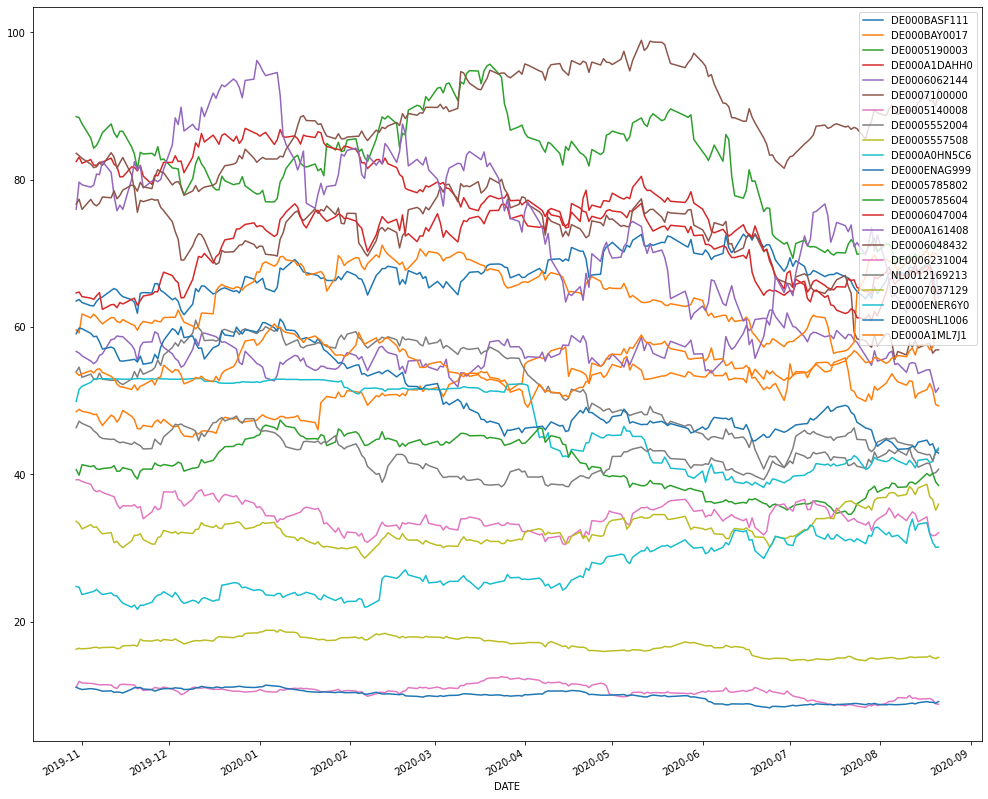

In [45]:
max_price = ts_dax.apply(max)
ts_dax[max_price[max_price < 100].index].plot(figsize=(17, 15))